# Generating Mock Data

## imports

In [1]:
# Without the following work-around line, pytorch is incompatible with agama
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


import agama
import numpy as np
import torch
from sbi.inference import NLE
from sbi.utils import BoxUniform
from sbi.inference import likelihood_estimator_based_potential
from sbi.analysis import conditional_pairplot

/Users/andyyu/Documents/Python/SUDS/suds/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set units
agama.setUnits(mass=1, length=1, velocity=1)

def make_potential(p_0: float, r_s: float, gamma: float) -> agama.Potential:
    """
    Makes potential according to GNFW profile
    
    - p_0: density normalization
    - r_s: scale radius
    - gamma: inner slope

    Preconditions:
    -   0 <= gamma <= 1
    """

    # Based on GNFW Profile
    param = {
        "type": "Spheroid", 
        "densityNorm": p_0,
        "scaleRadius": r_s,
        "gamma": gamma,
        "beta": 3,
        "alpha": 1
    }

    return agama.Potential(param)

def make_density(r_star: float):
    """
    Creates stellar density distribution according to the 3D Plummer Profile

    - r_star: scale length
    """

    # Based on Plummer profile
    param = {
        "type": "Spheroid",
        "mass": 1,
        "scaleRadius": r_star,
        "gamma": 0,
        "beta": 5,
        "alpha": 2,
    }
    
    return agama.Density(param)


def generate_galaxy(p_0: float, r_s: float, gamma: float, r_star: float, r_a: float):
    """
    Generate the galaxy model given theta

    - p_0: density normalization
    - r_s: scale radius
    - gamma: inner slope
    - r_star: scale length
    - r_a: the radius of transition from isotropic velocity orbits at small radii to radially biased orbits at larger radii (anisotropy radius).

    """

    pot = make_potential(p_0, r_s, gamma)

    df = agama.DistributionFunction(
        type = "QuasiSpherical",
        potential = pot,
        density = make_density(r_star),
        # anisType = "OsipkovMerritt",
        r_a = r_a
    )

    return agama.GalaxyModel(pot, df)

def transform_params(theta: torch.Tensor) -> torch.Tensor:
    """
    transform parameters into correct for generate_galaxy

    - theta: tensor of sampled theta with columns \
        log(p_0), log(r_s), gamma, r_star/r_s, r_a/r_star
    """


    p_0 = 10 ** theta[:,0]
    r_s = 10 ** theta[:,1]
    gamma = theta[:,2]
    r_star = theta[:,3] * r_s
    r_a = theta[:,4] * r_star

    return torch.stack([p_0, r_s, gamma, r_star, r_a], dim=1)


def generate_galaxy_bunch(theta: torch.Tensor) -> torch.Tensor:
    """
    Generate the galaxy model given theta

    - theta: tensor of sampled theta with columns \
        log(p_0), log(r_s), gamma, r_star/r_s, r_a/r_star
    """
    transformed_theta = transform_params(theta)
    
    samples_np = np.vstack([generate_galaxy(*row.tolist()).sample(1)[0][0] for row in transformed_theta])

    return torch.from_numpy(samples_np).to(torch.float32)  # sbi requires float 32

    
# torch.tensor(generate_galaxy(10e5, 10e2, 1, 0.3, 0.3).sample(1)[0][0])
# theta.shape[0]
# torch.zeros(theta.shape)
# torch.zeros([theta.shape[0], 6])

## Training

In [11]:
agama.setRandomSeed(13)
torch.manual_seed(13)

### Proof of concept

In [12]:
# Check table 1 from Nguyen et al. for prior values

# Create the prior boundary in following order: log(p_0), log(r_s), gamma, r_star/r_s, r_a/r_star
def generate_prior(n_samples: int):
    """
    Generate the thetas and x from uniform distribution of the prior
    """
    

    low = torch.tensor([5, -1, -1, 0.2, 0.5])
    high = torch.tensor([8, 0.7, 2, 1, 2])

    # Create uniform distribution
    prior = BoxUniform(low=low, high=high)

    # Sample from said distribution
    theta = prior.sample((n_samples,))

    # Generate the data
    x = generate_galaxy_bunch(theta)

    return prior, theta, x

prior, theta, x = generate_prior(100)

In [13]:
# Set up and train model
inference = NLE(prior=prior)
likelihood_estimator = inference.append_simulations(theta, x).train()

/Users/andyyu/Documents/Python/SUDS/suds/lib/python3.11/site-packages/sbi/inference/trainers/base.py:296: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 2, 3, 4, 5] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 220 epochs.

In [21]:
test_theta = torch.tensor([[5, 0, 1, 0.5, 0.5],])
test_x = generate_galaxy_bunch(test_theta)


In [19]:
torch.exp(likelihood_estimator.log_prob(test_x, condition=test_theta))


tensor([[0.0020]], grad_fn=<ExpBackward0>)

### Posterior

In [85]:
posterior = inference.build_posterior(likelihood_estimator)

In [86]:
samples = posterior.sample((1000,), x=test_x)

Running vectorized MCMC with 20 chains: 100%|██████████| 6000/6000 [00:56<00:00, 106.96it/s]


In [87]:
print(samples.mean(dim=0))
print(test_theta)

tensor([ 6.9200, -0.5218,  0.7042,  0.7250,  1.2682])
tensor([[7.1650, 0.6047, 1.2765, 0.8330, 0.8118]])


### Performance

In [ ]:
from sbi.diagnostics import run_sbc
# from sbi.analysis import sbc_rank_plot

# 50 test samples - should be 10000
theta_test = prior.sample((50,))
x_test = generate_galaxy_bunch(theta_test)

ranks = run_sbc(theta_test, x_test, posterior, num_posterior_samples=500)


Calculating ranks for 50 SBC samples: 100%|██████████| 50/50 [00:00<00:00, 2906.94it/s]


In [46]:
ranks[1]



tensor([[ 5.6117, -0.9066, -0.6956,  0.4203,  1.2382],
        [ 6.4777, -0.0424, -0.8481,  0.9724,  1.3297],
        [ 6.8252, -0.5421, -0.7103,  0.2875,  1.8713],
        [ 7.5623,  0.5150, -0.9765,  0.9886,  0.6830],
        [ 7.4047, -0.6319, -0.1908,  0.7343,  1.0707],
        [ 7.3748,  0.4895, -0.8016,  0.6558,  1.9545],
        [ 7.2368, -0.1414,  0.1393,  0.9013,  0.5446],
        [ 6.0902, -0.5775,  0.8173,  0.3914,  1.3870],
        [ 5.1746, -0.8614,  0.9720,  0.4298,  1.0453],
        [ 5.9107, -0.5453, -0.6058,  0.8251,  1.8156],
        [ 5.4953,  0.6659,  1.0915,  0.4683,  1.4299],
        [ 5.2879,  0.3988,  0.8376,  0.2216,  1.0503],
        [ 6.9651,  0.3528,  0.5215,  0.8097,  1.4939],
        [ 7.6349, -0.7508, -0.2374,  0.3091,  1.1143],
        [ 7.3616, -0.5359, -0.2306,  0.2217,  0.8324],
        [ 7.5376, -0.8033,  1.8805,  0.9621,  1.5763],
        [ 7.9777, -0.1458,  1.8219,  0.9624,  1.2850],
        [ 7.9975, -0.5738,  1.4912,  0.4991,  0.7633],
        [ 

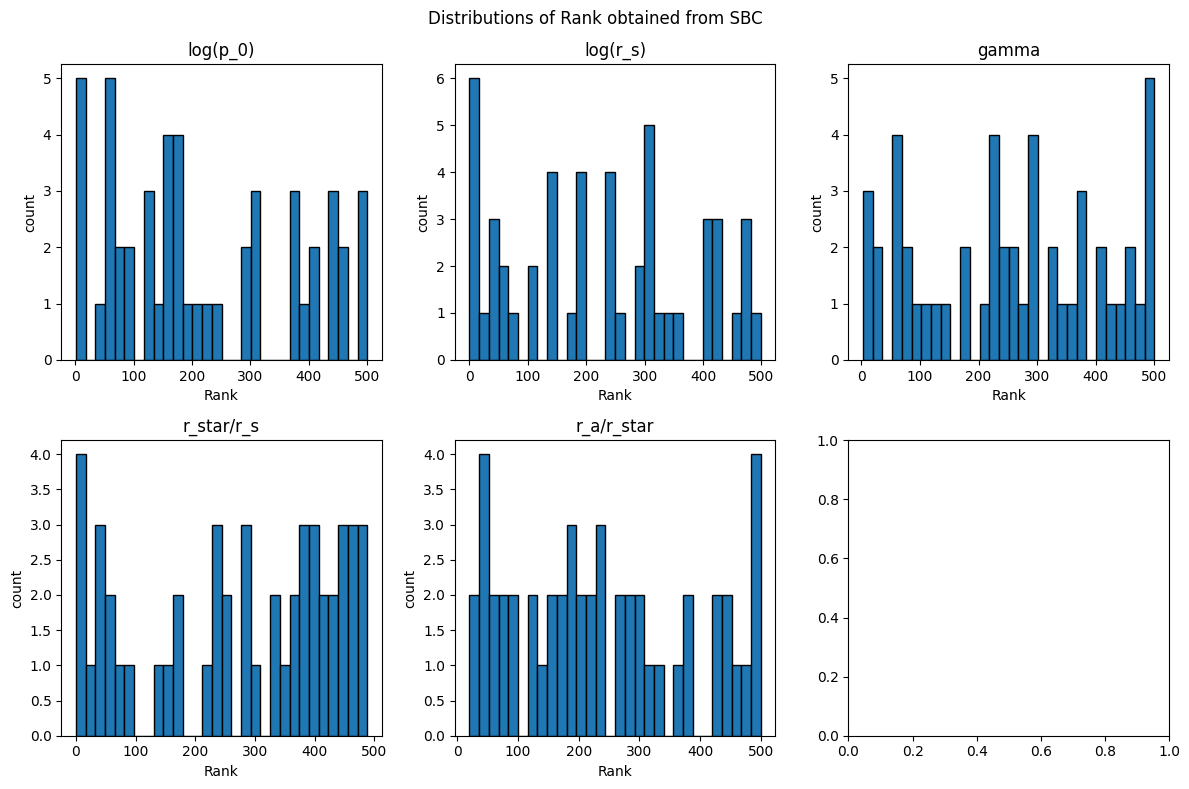

In [ ]:
import matplotlib.pyplot as plt

plot_titles= ["log(p_0)", "log(r_s)", "gamma", "r_star/r_s", "r_a/r_star"]

fig,axs= plt.subplots(2, 3, figsize=(12,8))

fig.suptitle("Distributions of Rank obtained from SBC")

# rank = # of samples less than \ntrue theta in each posterior sample
for i in range(3):
    axs[0, i].hist(ranks[0][:,i], bins=30, edgecolor="black")
    axs[0, i].set_title(plot_titles[i])
    axs[0, i].set_xlabel("Rank")
    axs[0, i].set_ylabel("count")

for i in range(2):
    axs[1, i].hist(ranks[0][:,i + 3], bins=30, edgecolor="black")
    axs[1, i].set_title(plot_titles[i + 3])
    axs[1, i].set_xlabel("Rank")
    axs[1, i].set_ylabel("count")

plt.tight_layout()
plt.show()

### Hypothesis Testing

In [73]:
from sbi.diagnostics import calc_misspecification_logprob

test_theta = prior.sample((1,))
test_x = generate_galaxy_bunch(prior.sample((1,)))

In [75]:

sample_theta = prior.sample((1000,))
x_val = generate_galaxy_bunch(sample_theta)

In [ ]:
# Unconditional estimator for fixed theta
from sbi.neural_nets.estimators import UnconditionalDensityEstimator
class UnconditionalEstimator():
    def __init__(self, model, theta):
        # super().__init__()
        self.model = model
        self.theta = theta

    def log_prob(self, x):
        return self.model.log_prob(x, condition= self.theta.repeat(x.shape[0], 1))
    
    


In [63]:
a = UnconditionalEstimator(likelihood_estimator, test_theta)

In [72]:
# a.theta
test_x.shape

torch.Size([1, 5])

In [68]:
a.log_prob(generate_galaxy_bunch(test_theta))

tensor([[-10.0066,  -5.1364,  -9.9083, -13.4259,  -9.5116,  -9.7737, -13.5220,
         -12.8171,  -6.2870, -14.6676,  -7.2843,  -9.4507, -16.9688, -11.7110,
         -10.6786, -10.6550,  -4.6543, -10.3796,  -9.9561,  -9.5659, -10.7424,
          -7.9748,  -6.2329, -18.1140,  -6.1230,  -8.3160, -20.1569,  -4.7743,
          -6.9913,  -9.7815, -10.1666,  -9.5004, -11.9730, -16.1069, -12.7717,
         -11.1038,  -9.0079, -10.2789,  -9.3477,  -5.7846, -11.8339, -15.7596,
          -7.4043, -12.9925,  -9.3354,  -7.1244, -10.4841, -13.0167, -12.9277,
          -8.2852, -10.8306, -17.4314, -10.2228, -11.6953,  -8.9795,  -7.4786,
         -19.6991,  -8.2712,  -6.8810, -15.4612,  -8.0689, -20.2422, -11.7227,
          -5.3757, -19.7808,  -5.2223,  -8.3774, -11.0294, -13.6478, -14.2448,
         -14.7541, -13.7563,  -6.9172, -13.4820, -10.7549, -15.9738, -13.5461,
          -8.1773,  -7.9233, -10.6645, -10.4324,  -4.8757,  -7.9058,  -8.2591,
          -8.8009, -12.1545, -12.1386,  -5.2715,  -6

In [84]:
calc_misspecification_logprob(x_val, test_x, UnconditionalEstimator(likelihood_estimator, test_theta))


TypeError: Can't instantiate abstract class UnconditionalEstimator with abstract methods loss, sample

### MCMC

In [14]:
import emcee

In [ ]:
class EmceePosteriorWrapper:
    def __init__(self, model, x_obs, prior):
        self.model = model
        # Ensure the observation is always (1, 6)
        self.x_obs = x_obs.view(1, -1) 
        self.prior = prior

    def __call__(self, theta_np):
        """
        emcee calls this function. 
        theta_np is a numpy array of shape (5,)
        """
        # 1. Convert to torch (1, 5)
        theta = torch.as_tensor(theta_np, dtype=torch.float32).view(1, -1)

        # 2. Log-Prior range check
        lp = self.prior.log_prob(theta).item()
        if lp == -float('inf'):
            return -np.inf # so always lower probability and MCMC will not go to this step

        # 3. Log-Likelihood from NLE
        # We use no_grad because emcee doesn't need derivatives
        with torch.no_grad():
            try:
                # log p(x_obs | theta)
                # First arg: Data (Size 6), Second arg: Condition (Size 5)
                ll = self.model.log_prob(self.x_obs, condition=theta).item()
            except Exception:
                # If the neural network hits a numerical error, reject the step
                return -np.inf

        # Posterior = Prior + Likelihood
        return lp + ll

# --- Execution ---

# 1. Prepare data
th_true = prior.sample((1,))
x_obs = generate_galaxy_bunch(th_true)

# 2. Initialize our callable wrapper
# We include the prior here so the MCMC knows the boundaries
post_func = EmceePosteriorWrapper(likelihood_estimator, x_obs, prior)

# 3. Setup emcee
ndim = 5
nwalkers = 32
sampler = emcee.EnsembleSampler(nwalkers, ndim, post_func)

# 4. Start walkers in a small cloud around a random spot in the prior
initial_pos = prior.sample((nwalkers,)).numpy()

# 5. Run MCMC
print("Starting MCMC...")
sampler.run_mcmc(initial_pos, 500, progress=True)

# 6. View results (ignoring the first 100 steps of burn-in)
samples = sampler.get_chain(discard=100, flat=True)
print(f"Sampled {samples.shape[0]} points from the posterior.")

Starting MCMC...


100%|██████████| 500/500 [00:26<00:00, 19.13it/s]

Sampled 12800 points from the posterior.


In [ ]:
# marginal median vs truth
print(np.median(samples, axis=0)   )
print(th_true)

[6.8705411  0.211622   1.00636864 0.57432908 1.40997803]
tensor([[ 7.4921, -0.0217,  0.7656,  0.6828,  0.7396]])
